# Lab 6 CNNs
Group Members: David Guo, Zi Ling

## 1. Preparation

### 1.1 Dataset Introduction

We use the same dataset we have in Lab2, which is the Garbage Classification Dataset from Kaggle (https://www.kaggle.com/datasets/zlatan599/garbage-dataset-classification/data). 

It provides a clean and well-balanced collection of images for automated waste-sorting tasks. The orginal dataset contains 6 categories of cardboard, glass, metal, paper, plastics, and trash, and for each category has 2,300 to 2,500 256x256x3 RGB images.

### 1.2 Resize, Grayscale and Train/test Split

In [32]:
# read images, resize, grayscale, split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_ds = keras.utils.image_dataset_from_directory(
	"images",
	labels="inferred", 
	label_mode="int", # turn labels into 0,1,2,... # note: + sparse_categorical_crossentropy
	color_mode="grayscale",
	batch_size=64,
	image_size=(64, 64),   
	shuffle=True,
	seed=42,
	validation_split=0.2,
	subset="training"
)

test_ds = keras.utils.image_dataset_from_directory(
	"images",
	labels="inferred",
	label_mode="int",
	color_mode="grayscale",
	batch_size=64,
	image_size=(64, 64),
	shuffle=True,
	seed=42,
	validation_split=0.2,
	subset="validation"
)

train_class_names = train_ds.class_names
test_class_names = test_ds.class_names

print("Train", train_class_names)
print("Test", test_class_names)

Found 13901 files belonging to 6 classes.
Using 11121 files for training.
Found 13901 files belonging to 6 classes.
Using 2780 files for validation.
Train ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


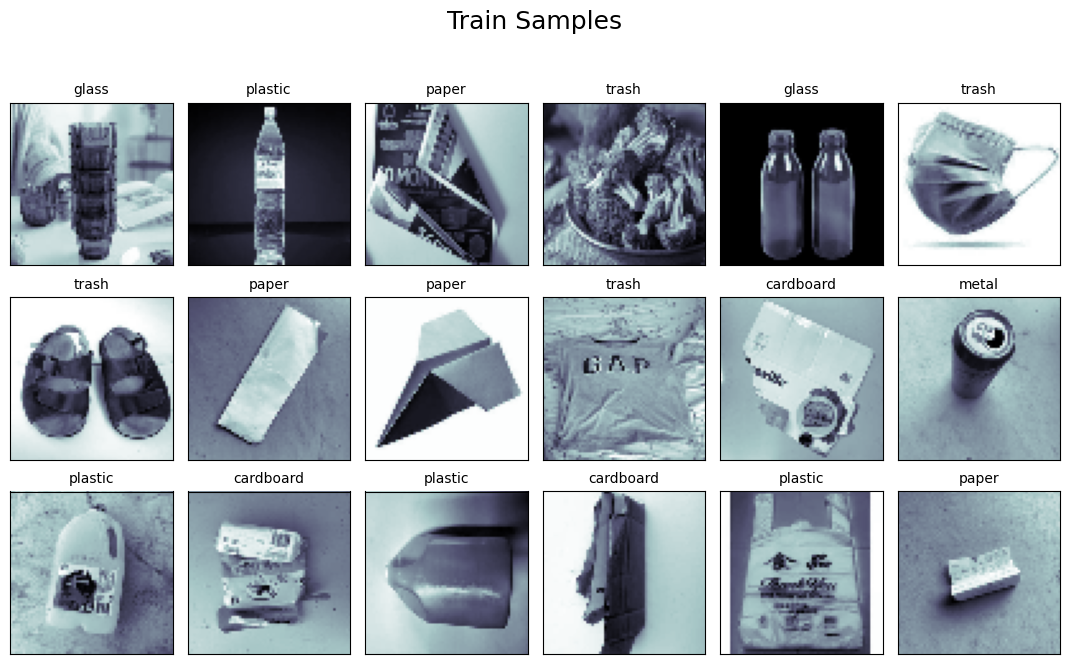

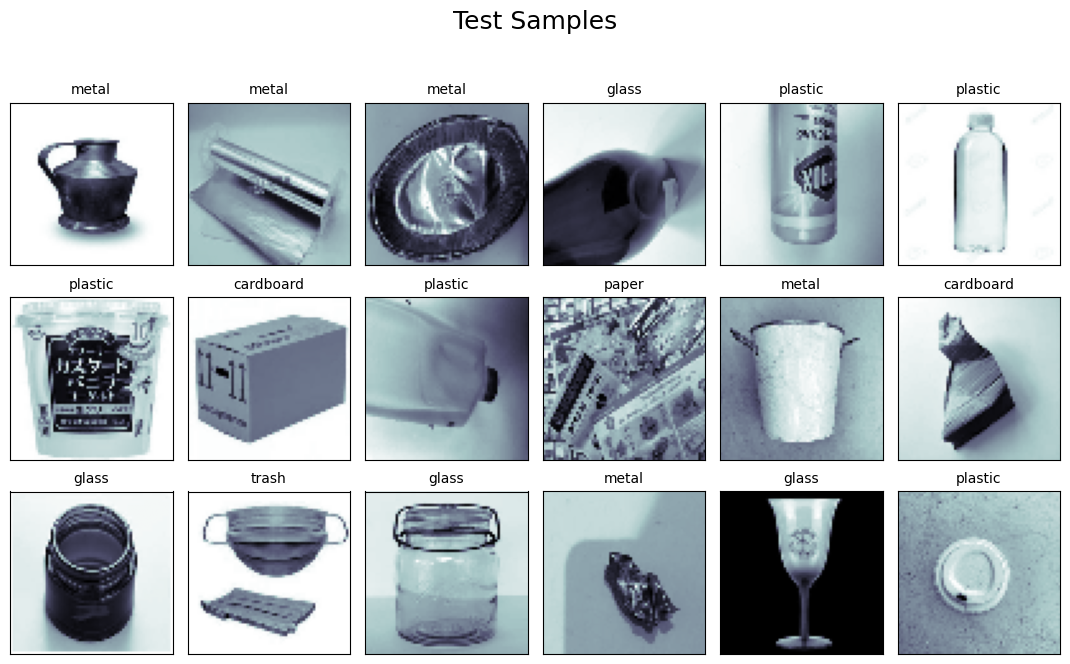

In [33]:
# show samples images

import matplotlib.pyplot as plt

def plot_gallery(ds, class_names, n_row=3, n_col=6, title="Sample images"):
    # Take 1 batch (default batch size: your dataset batch size)
    for images, labels in ds.take(1):
        images = images.numpy()
        labels = labels.numpy()
        break  # just to be explicit

    plt.figure(figsize=(1.8 * n_col, 2.3 * n_row))
    plt.suptitle(title, fontsize=18)

    total = n_row * n_col

    for i in range(total):
        plt.subplot(n_row, n_col, i + 1)
        img = images[i].squeeze()

        # if grayscale (64×64×1), remove channel for plotting
        if img.ndim == 2:
            plt.imshow(img, cmap="bone")
        else:
            plt.imshow(img.astype("uint8"))

        plt.title(class_names[labels[i]], fontsize=10)
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_gallery(train_ds, train_class_names, n_row=3, n_col=6, title="Train Samples")
plot_gallery(test_ds, test_class_names, n_row=3, n_col=6, title="Test Samples")

In [34]:
# check class balance
# ask GPT to give me the simplest code to count number of labels in a tf dataset
from collections import Counter

def count_labels(ds, class_names):
	counter = Counter()

	for _, labels in ds:
		counter.update(labels.numpy())

	return {class_names[i]: counter[i] for i in range(len(class_names))}

train_counts = count_labels(train_ds, train_ds.class_names)
test_counts = count_labels(test_ds, test_ds.class_names)

print("Train counts:", train_counts)
print("Val counts:", test_counts)

#Normalizing the dataset
def normalize_image(image, label):
		# Scale pixel values to [0, 1]
		image = image / 255.0
		return image, label

train_ds = train_ds.map(normalize_image)
test_ds = test_ds.map(normalize_image)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

Train counts: {'cardboard': 1777, 'glass': 2026, 'metal': 1666, 'paper': 1837, 'plastic': 1826, 'trash': 1989}
Val counts: {'cardboard': 437, 'glass': 474, 'metal': 418, 'paper': 478, 'plastic': 462, 'trash': 511}


To prepare the dataset for modeling, we used Keras’s image_dataset_from_directory, which automatically loads images and assigns labels based on the folder names. The labels were stored as integer class IDs, which allows us to train our CNN using sparse_categorical_crossentropy without converting them into one-hot vectors.

All images were resized to 64×64 pixels and grayscaled, to simplify computation while still preserving meaningful visual information for classification. They plot shows the reshaped images are still able to recongized.

#### train/test split
For the train/test split, we used Keras’s built-in validation_split=0.2 with subset="training" and "validation", which performs an 80/20 stratified split. Thisksplit keeps the class distribution consistent across both sets. And since our dataset is already reasonably balanced across all six categories, a stratified hold-out split is sufficient. Morover, deep CNNs are expensive to train, so in practice, garbage-sorting models are usually trained once on a large batch of collected images and then evaluated on a separate subset, since our data volume is sufficient, model can learn patterns from 80% training set, there is not efficient to repeatedly retrain 10 times using cross-validation folds. Because of this, an 80/20 stratified split gives us a realistic, production-style setup without the heavy cost of k-fold cross-validation.

The final result is two clean, normalized, and well-structured datasets (train_ds and test_ds) ready for data augmentation and CNN modeling.

### 1.3 Measure of Performance Discussion
For this task, accuracy alone is not enough because it does not reflect which types of mistakes are more harmful. In real garbage-sorting systems, some categories are higher-risk, missing them can cause contamination or safety issues. For example, glass often breaks during disposal and transportation, which may injure workers, damage sorting machines, and contaminate the recycling streams[1], and metal has enviromental toxicity and release harmful chemicals[2], and trash contamination ruins entire recycling batches, may cause the cardboard, paper and plastic unrecycable[3].  Other categories like paper, cardboard, and plastic are lower-risk, and confusion among them is less serious.

Because different classes have different risks, using a single F1-score for all of them is not appropriate. F1 gives precision and recall equal weight, but high-risk categories require stronger emphasis on recall, since missing these items is more costly than detecting too many.

Therefore, we evaluate each class separately using:
1. Fbeta-score (recall-weighted) for high-risk classes: glass, metal, trash.
2. F1-score for lower-risk classes: cardboard, paper, plastic.

Finally, we combine these six class-specific F-scores into a single weighted average overall performance metric. Given that the high-risk categories (glass, metal, trash) are considered twice as critical as the lower-risk categories (cardboard, paper, plastic), we assign a weight of 2 to each high-risk Fbeta-score and a weight of 1 to each low-risk F1-score. 

The overall performance is calculated by:

$$\text{Final Score} = \frac{2 \cdot (\text{glass\_Fbeta} + \text{metal\_Fbeta} + \text{trash\_Fbeta}) + \text{paper\_F1} + \text{plastic\_F1} + \text{cardboard\_F1}}{9}$$

This weighted approach directly reflects the business priority of minimizing critical errors in high-risk waste separation.

Reference:

[1] WasteManaged, “What Happens to Glass Waste?” Waste Managed News. [Online]. Available: https://www.wastemanaged.co.uk/our-news/glass-waste/what-happens-to-glass-waste/

[2] Okon Recycling, “Environmental Impact of Metal Waste.” Available: https://www.okonrecycling.com/industrial-scrap-metal-recycling/steel-and-aluminum/environmental-impact-of-metal-waste/

[3] UW Sustainability, “Recycling contamination.” [Online]. Available: https://sustainability.uw.edu/blog/recycling-contamination

# 2. Modeling

### 2.1 Model 1 1-Layer CNN

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2643 - loss: 1.8037 - val_accuracy: 0.3320 - val_loss: 1.7726
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3613 - loss: 1.6075 - val_accuracy: 0.3763 - val_loss: 1.6163
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3751 - loss: 1.5679 - val_accuracy: 0.3957 - val_loss: 1.5763
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3859 - loss: 1.5479 - val_accuracy: 0.3935 - val_loss: 1.6362
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3975 - loss: 1.5233 - val_accuracy: 0.3849 - val_loss: 1.6342
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4055 - loss: 1.5057 - val_accuracy: 0.3522 - val_loss: 1.8591
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4100 - loss: 1.5015 - val_accuracy: 0.4047 - val_loss: 1.5840
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4102 - loss: 1.4869 - val_accu

Model: "Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_4            │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │       196,614 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,870 (1.50 MB)

 Trainable params: 196,934 (769.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 196,936 (769.29 KB)

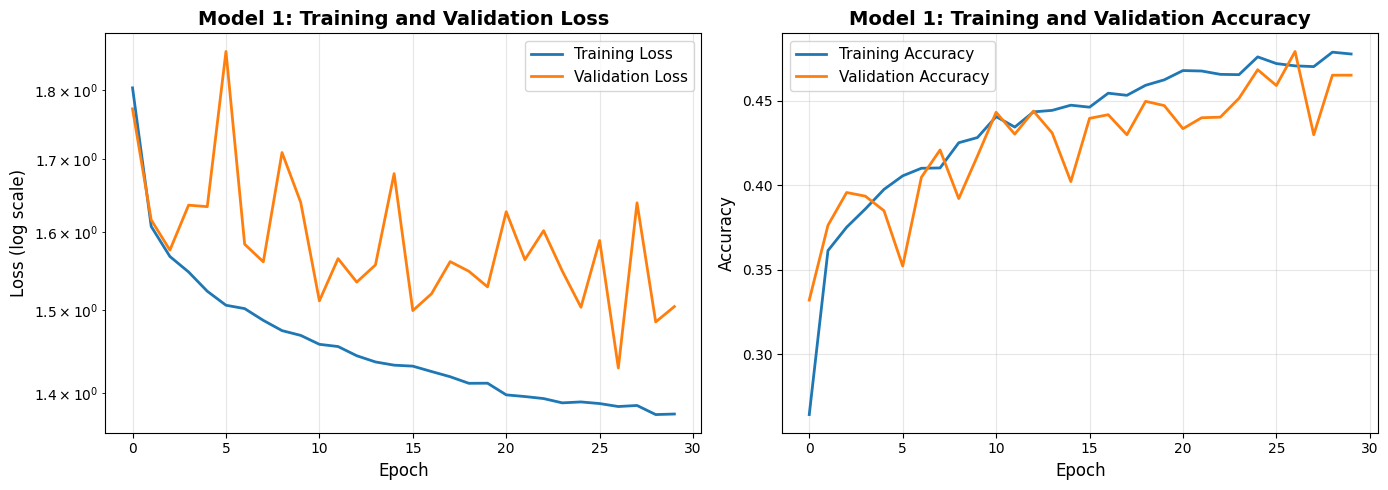

In [35]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Activation, Flatten, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomTranslation
from tensorflow.keras.layers import RandomContrast, RandomBrightness

def create_cnn_model_1(model_name, input_shape = [64,64,1], kernel_size= (3,3), pool_size=(2,2), 
					 filters_per_conv_layer = [32], # number of filters to use and how many convolutional layers to use 
					 dense_layer_sizes = [6], # number of neurons in each layer after flattening
					 use_dropout=False
					):
	
	cnn  = Sequential(name=model_name)
	cnn.add(Input(input_shape))

	cnn.add(RandomFlip("horizontal")) # flip horizontally
	cnn.add(RandomRotation(0.05)) # rotate by 5%
	cnn.add(RandomTranslation(height_factor=0.1, width_factor=0.1)) # move by 10%

	# convolutional layers
	for num_filters in filters_per_conv_layer:
		cnn.add(Conv2D(filters=num_filters, 
						kernel_size=kernel_size, 
						padding='same',
						activation='relu',
						 ))
		
		cnn.add(MaxPooling2D(pool_size=pool_size))
		
	cnn.add(Flatten())
	for i, num_hidden in enumerate(dense_layer_sizes[:-1]):
		cnn.add(Dense(num_hidden, activation='relu'))
		# optionally use Dropout
		if use_dropout and i < len(dense_layer_sizes[:-1]) - 1:
			cnn.add(Dropout(0.2))
			
	# final layer for classes
	cnn.add(Dense(dense_layer_sizes[-1], activation='softmax'))
	
	return cnn

model_1 = create_cnn_model_1("Model1")

model_1.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history1 = model_1.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_1.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history1.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history1.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 1: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history1.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history1.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 1: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Augmentation methods

We used horizontal flipping, small rotations, and slight translations in the augmentation. These choices make sense for this dataset because garbage items can appear anywhere in the frame and usually do not have a strict orientation. A piece of cardboard, plastic bottle, or metal should be the same class even if it is rotated slightly or placed on the left or right side of the image. Translation helps the model learn that the object’s position is irrelevant, and rotation improves robustness to camera angle changes.

So, these augmentation techniques reflect realistic variations in real garbage-sorting environments and make the model more robust without altering the fundamental visual characteristics of the objects.

#### Analysis

Model 1 is a simple forward feed cnn model with a kernel size of 3x3 and a filter of 32, with a single dense layer of 6. After running the model and graphing it for the loss on the graph, we see that the model's training loss has converged, while the validation is flunctuating, and the two accuracy curves stay close to each other to around 47%. While it doesn't show that the model is overfitting, it clearly shows that the model is struggling to be trained on. This is due to us creating a one filter layer with a small 1x1 kernel size, which does not extract useful information for the model to be trained on. 

Overall, the model 1 is too simple so it can not learn much due to the one layer, and a kernel size of 1x1 which is heavily restricts its learning ability.

### 2.2 Model 2

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2141 - loss: 1.7668 - val_accuracy: 0.2680 - val_loss: 1.7021
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.2712 - loss: 1.7021 - val_accuracy: 0.3284 - val_loss: 1.6310
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3193 - loss: 1.6498 - val_accuracy: 0.3543 - val_loss: 1.5806
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3458 - loss: 1.6046 - val_accuracy: 0.3655 - val_loss: 1.5898
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3729 - loss: 1.5586 - val_accuracy: 0.4237 - val_loss: 1.4520
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4001 - loss: 1.5114 - val_accuracy: 0.4403 - val_loss: 1.4376
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4174 - loss: 1.4835 - val_accuracy: 0.4604 - val_loss: 1.4010
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4394 - loss: 1.4422 - val_accu

Model: "Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_5            │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,239,470 (4.73 MB)

 Trainable params: 619,734 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 619,736 (2.36 MB)

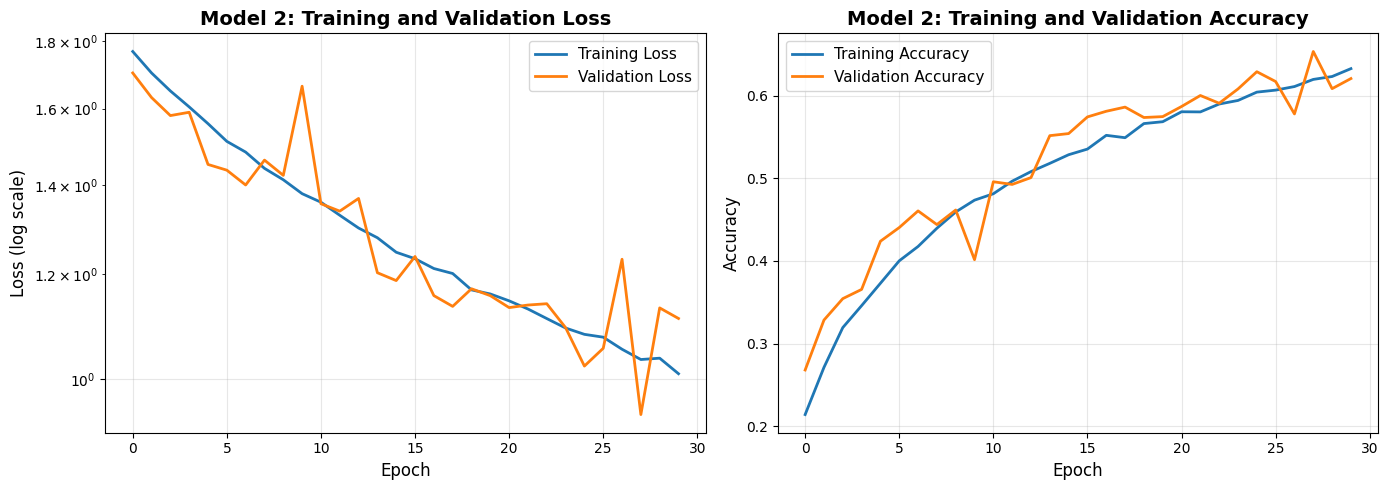

In [36]:
model_2 = create_cnn_model_1("Model1", 
															kernel_size=(3,3), 
															pool_size=(2,2), 
															filters_per_conv_layer = [32, 64, 128], 
															dense_layer_sizes = [64, 32, 16, 6], 
															use_dropout=True
															)

model_2.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history2 = model_2.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_2.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history2.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history2.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 2: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history2.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history2.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 2: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

For model 2, we use the same basic feedforward CNN architecture as Model 1, but added 3 filter layers of 32, 64, and 128, along with a 4 dense layer of 64, 32, 16, and 6. The kernel size remains the same for all filter layers at 3x3. We are using dropout along with data augmentation to help preventing overfitting.

The loss curves shows that both training, and validation are converging, the training has a smooth curve, while the validation is showing flucuanting result. The loss curves for both are close to another showning that the model is not overfitting the data, and it shows that the model is able to learn well from the filter layers. 

Compared to model 1, model 2 achieves better performance with around 62-63% in training and testing. The upwards trends supports that the model is learning well from the feature it is extracting from. 

### 2.3 Model 3

In [37]:
# Asked Gpt to help with a debugging for parallel network
def create_branches(input, layers):
	branch = input
	for filters_per_conv_layer, kernel_size in layers:
		branch = Conv2D(filters=filters_per_conv_layer, kernel_size=kernel_size, padding='same', activation='relu')(branch)
		
	return branch


def create_cnn_model_2(input_shape = [64,64,1], pool_size=(2,2), 
										 num_branches = [
											[(32, (3,3))], 
											[(32, (1,1)), (64, (3,3))],
											[(32, (1,1)), (64, (3,3)), (64, (3,3))]
										 ], # number of filters to use and how many convolutional layers to use 
										 dense_layer_sizes = [6], # number of neurons in each layer after flattening
										 use_dropout=False
										):
		
	input = Input(input_shape)
	
	x = RandomFlip("horizontal")(input) # flip horizontally
	x = RandomRotation(0.05)(x) # rotate by 5%
	x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x) # move by 10%
	x = RandomBrightness(factor=0.1, value_range=(0.0, 1.0))(x) # add some to the mean
	x = RandomContrast(0.1)(x) # add or decrease contrast


	#Create another Con2D here and then do max pool and then do branches
	x = Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
	x = MaxPooling2D(pool_size=pool_size)(x)

	parallel_pathways_list = []
	# convolutional layers
	for branches_config in num_branches:
		result = create_branches(x, branches_config)
		parallel_pathways_list.append(result)
	
	x = Concatenate(axis=-1)(parallel_pathways_list)	
	x = MaxPooling2D(pool_size=pool_size)(x)

	x = Flatten()(x)

	for i, num_hidden in enumerate(dense_layer_sizes[:-1]):
		x = Dense(num_hidden, activation='relu')(x)
		# optionally use Dropout
		if use_dropout and i < len(dense_layer_sizes[:-1]) - 1:
			x = Dropout(0.2)(x)

	# final layer for classes
	x = Dense(dense_layer_sizes[-1], activation='softmax')(x)
	
	return Model(inputs=input, outputs=x, name='Inception')

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.2140 - loss: 1.7608 - val_accuracy: 0.2881 - val_loss: 1.6985
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.2785 - loss: 1.6979 - val_accuracy: 0.3486 - val_loss: 1.6180
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3183 - loss: 1.6438 - val_accuracy: 0.3701 - val_loss: 1.5656
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3436 - loss: 1.6085 - val_accuracy: 0.3590 - val_loss: 1.5743
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3555 - loss: 1.5806 - val_accuracy: 0.3640 - val_loss: 1.5829
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3742 - loss: 1.5537 - val_accuracy: 0.4227 - val_loss: 1.4514
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3907 - loss: 1.5262 - val_accuracy: 0.4460 - val_loss: 1.4328
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3994 - loss: 1.5129 - val_accu

Model: "Inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_6       │ (None, 64, 64, 1) │          0 │ input_layer_11[0… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_6   │ (None, 64, 64, 1) │          0 │ random_flip_6[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 64, 64, 1) │          0 │ random_rotation_… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_2 │ (None, 64, 64, 1) │          0 │ random_translati… │
│ (RandomBrightness)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_2   │ (None, 64, 64, 1) │          0 │ random_brightnes… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │        640 │ random_contrast_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 32, 32,    │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     18,464 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     18,496 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ conv2d_20[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ concatenate_2[0]… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 24576)     │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │  1,572,928 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 32)        │      2,080 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,845,956 (18.49 MB)

 Trainable params: 1,615,318 (6.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,230,638 (12.32 MB)

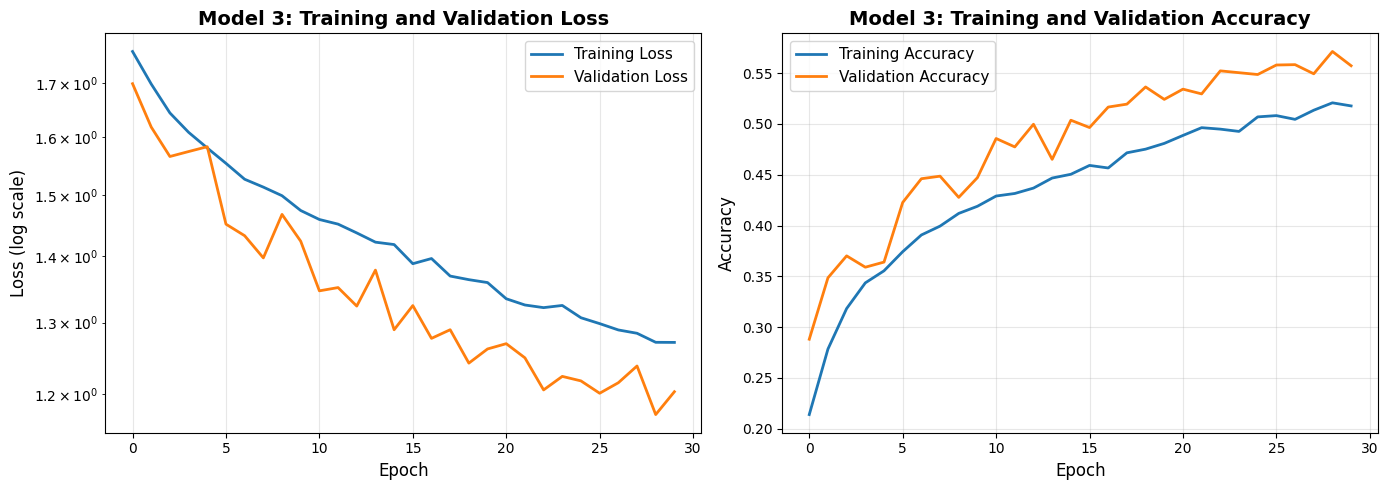

In [38]:
model_3 = create_cnn_model_2(num_branches = [
											[(32, (3,3))], 
											[(32, (1,1)), (64, (3,3))],
										 ], dense_layer_sizes = [64, 32, 16, 6], use_dropout=True)

model_3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history3 = model_3.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_3.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history3.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history3.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 3: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history3.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history3.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 3: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

For model 3, we are using parallel pathways with 1 branch of 32 filter, and a kernel size of 3x3. The second branch is using 2 convolatiion layer of 32 filter with a kernel size of 1x1, and a second layer of 64 filter with a 3x3 kernel size. We deciede to go with two branches as the branch 1 can be used to extract low level features, while the second branch can capture more information from the image with its two conculation layers. After concatenating them, we apply a maxpooling of size 2x2 with the deafult stride which gets the max value, and this is passed to the dense layer of 64, 32, 16, 6 with a dropout of 0.2 between hidden layers to reduce overfitting. 

Both the training, and the validation curve loss are converging, with training accuracy rises to about 52%, while validation accuracy reaches around 56% by the end of training, showing that the model is learning effectively. The fluctating validation loss could be due to dropout, and data augmentation happening during training phase. Moreover, the validation is close to the training loss indicating the model is not overfitting, and the model is learning steadily after each epochs. 

The loss curve trend also supports the accuracy curve where the accuracy is increasing after each epochs, and the reason the validation is higher than the training as the data augmentation and dropout only happens during the training phase. This shows that the model generalizes well. 

Compared to the simple CNN in Model 1, Model 3 achieves higher validation accuracy and learns more expressive features by combining multiple receptive fields through the parallel branches. But compared to model 2, its performance is slightly lower.

### 2.4 Model 4

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.2519 - loss: 1.7245 - val_accuracy: 0.3183 - val_loss: 1.6284
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.3482 - loss: 1.6066 - val_accuracy: 0.3817 - val_loss: 1.5558
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.3977 - loss: 1.5276 - val_accuracy: 0.4004 - val_loss: 1.5329
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.4215 - loss: 1.4766 - val_accuracy: 0.4050 - val_loss: 1.5462
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.4436 - loss: 1.4419 - val_accuracy: 0.4259 - val_loss: 1.4452
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.4605 - loss: 1.4001 - val_accuracy: 0.4532 - val_loss: 1.4116
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.4665 - loss: 1.3826 - val_accuracy: 0.4586 - val_loss: 1.4075
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.4781 - loss: 1.3512 - 

Model: "Inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_7       │ (None, 64, 64, 1) │          0 │ input_layer_12[0… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_7   │ (None, 64, 64, 1) │          0 │ random_flip_7[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 64, 64, 1) │          0 │ random_rotation_… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_3 │ (None, 64, 64, 1) │          0 │ random_translati… │
│ (RandomBrightness)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_3   │ (None, 64, 64, 1) │          0 │ random_brightnes… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │        640 │ random_contrast_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_14… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_14… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │     18,496 │ conv2d_27[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     18,464 │ max_pooling2d_14… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     18,496 │ conv2d_25[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_28[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ conv2d_24[0][0],  │
│ (Concatenate)       │ 160)              │            │ conv2d_26[0][0],  │
│                     │                   │            │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 16, 16,    │          0 │ concatenate_3[0]… │
│ (MaxPooling2D)      │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,164,196 (31.14 MB)

 Trainable params: 2,721,398 (10.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,442,798 (20.76 MB)

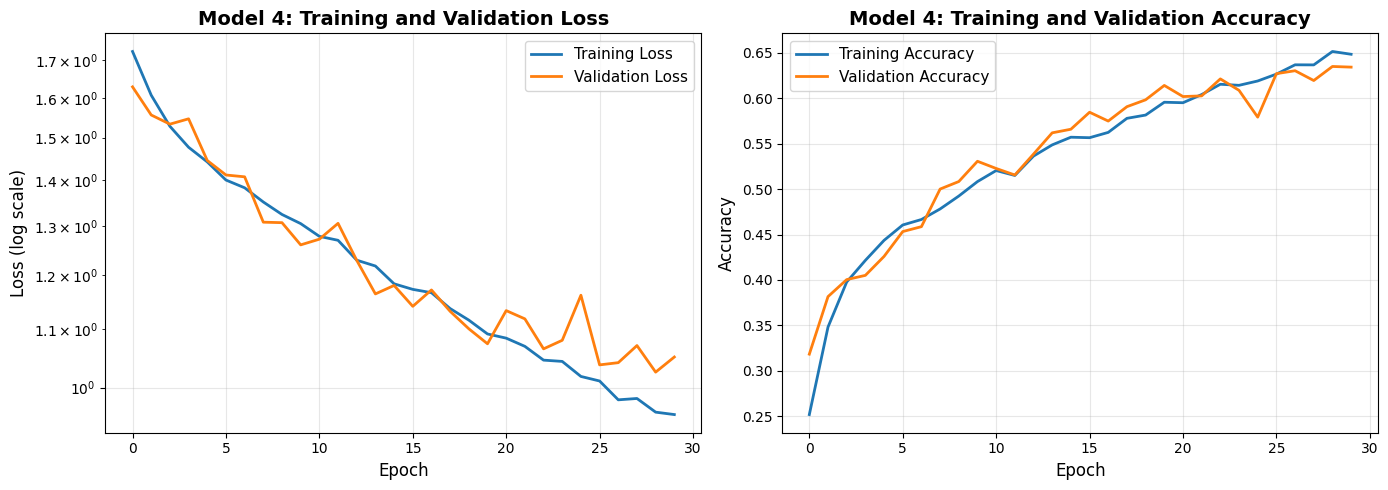

In [39]:
model_4 = create_cnn_model_2(num_branches = [
											[(32, (3,3))], 
											[(32, (1,1)), (64, (3,3))],
											[(32, (1,1)), (64, (3,3)), (64, (3,3))]
										 ], dense_layer_sizes = [64, 32, 16, 6], use_dropout=False)

model_4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history4 = model_4.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

model_4.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history4.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history4.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Model 4: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history4.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history4.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model 4: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

Mdoel 4 extends the model 3 by adding one more branch of one convulation layer of 32 filter with a 1x1, followed by 2 64 filter layers of 3x3 kernel size. This added branch allows the model to extract more features, at a higher level. After concatenating all of the branches, we then pass it along to the same amount of dense layers as model 3, but dropout is disabled. 

Both the loss curves is decreasing slowly, and are verly close to each other for the entire epochs of 30. This indicates that the model is not overfitting, generlizes well, and is effecting learning after each epochs. The closeness of the curves indicates that the model is fitting the training data well, and also on unseen data. 

The accuracy curves also follows the similar trend of loss curve where the accuracy is increasing steadily, with the training and testing accuracy reaches acound 64%, and also nearly overlapping each other as well. 

Compared to previous models, model 4 achieves an overall better accuracy outcomes, with 63-65% in training and testing accuracy. However, the performance gap between model 2 and model 4 is relatively small and can be affected by training randomness, but across our runs model 4 tends to achieve the best validation accuracy overall.

### 2.5 Calculating the F Scores for the classes

In [40]:
#Asked GPT for some weighted f1 help
import numpy as np
from sklearn.metrics import f1_score, fbeta_score
from pprint import pprint

y_true = np.concatenate([y for _, y in test_ds], axis=0)

models_dict = {
	"model_1": model_1,
	"model_2": model_2,
	"model_3": model_3,
	"model_4": model_4
}

models_f2_dict = {
	"model_1": None,
	"model_2": None,
	"model_3": None,
	"model_4": None
}

cardboard = 0
glass = 1
metal = 2
paper = 3
plastic = 4
trash = 5

high_risk = [glass, metal, trash]
low_risk = [cardboard, paper, plastic]

model_pred_result = {
	"model_1": None,
	"model_2": None,
	"model_3": None,
	"model_4": None
}

for model_name in models_dict:
	y_pred_probs = models_dict[model_name].predict(test_ds)
	y_pred = np.argmax(y_pred_probs, axis=1)

	model_pred_result[model_name] = y_pred
	
	f2_high_risk = fbeta_score(y_true, y_pred, beta=2, average=None)
	f1_low_risk = f1_score(y_true, y_pred, average=None)

	glass_f2 = f2_high_risk[glass]
	metal_f2 = f2_high_risk[metal]
	trash_f2 = f2_high_risk[trash]

	paper_f1 = f1_low_risk[paper]
	plastic_f1 = f1_low_risk[plastic]
	cardboard_f1 = f1_low_risk[cardboard]

	final_score = ( 2*(glass_f2 + metal_f2 + trash_f2) + paper_f1 + plastic_f1 + cardboard_f1 ) / 9

	models_f2_dict[model_name] = final_score


pprint(models_f2_dict)
print("The Best Model is ", max(models_f2_dict, key=models_f2_dict.get))
print("The Best Model score is", models_f2_dict[max(models_f2_dict, key=models_f2_dict.get)])

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
{'model_1': np.float64(0.16042562641601021),
 'model_2': np.float64(0.176842187766869),
 'model_3': np.float64(0.1661683384305731),
 'model_4': np.float64(0.15855283282418153)}
The Best Model is  model_2
The Best Model score is 0.176842187766869


#### Analysis

We decided to go with a weighted evaluation metric. Since we mention that high risk are glass, metal, and trash, we gave them a 2 times multiplier so that the weight more in the final result as compared to low risk, and then we took the average of the result. 

<br>
After looking at the result, we can see that the model 2 is the best performer but the score is really low suggesting the that the misclassification is high. All the other models were roughly the same performer as well. This suggest that despite having a good validation accuracy for model 2 and 4, the model were not able to correctly label the classes accurate. 

There could be multiple different reasons why the our model is not performing great. Maybe our model is too shallow, or parallel pathway is not a good technique to do classifications for our datasets, or the weight we designed for the high risk garbage is too heavy for the average.

If we have to apply the model in practice, model 2 is the approprate one because it has close accuracy with model 4 and better F score performance under our risk-aware evaluation metric.


### 2.6 Statitical Comparison between the models

In [41]:
from statsmodels.stats.contingency_tables import mcnemar
import itertools

result = {}
model_names = ["model_1", "model_2", "model_3", "model_4"]

def mcNemar_table(y_true, model_1_pred, model_2_pred):
	model1_correct = model_1_pred == y_true
	model2_correct = model_2_pred == y_true

	both_correct = np.sum(model1_correct & model2_correct)
	model1_correct_model2_wrong = np.sum(model1_correct & ~model2_correct)
	model2correct_model1_wrong = np.sum(~model1_correct & model2_correct)
	both_wrong = np.sum(~model1_correct & ~model2_correct)

	return np.array([[both_correct, model1_correct_model2_wrong], [model2correct_model1_wrong, both_wrong]])

for model1, model2 in itertools.combinations(model_names, 2):
	table = mcNemar_table(y_true, model_pred_result[model1], model_pred_result[model2])
	result_mcnemar = mcnemar(table, exact=False, correction=True)
	result[(model1, model2)] = {
			"statistic": result_mcnemar.statistic,
			"p-value": result_mcnemar.pvalue
		}

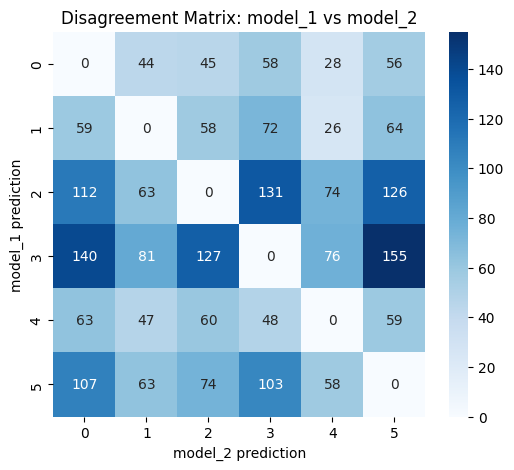

mcNemar Result {'statistic': np.float64(3.486595174262735), 'p-value': np.float64(0.061867707873706365)}


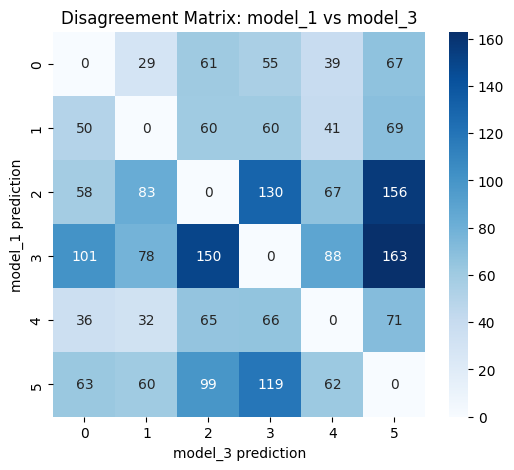

mcNemar Result {'statistic': np.float64(0.26666666666666666), 'p-value': np.float64(0.6055766163353463)}


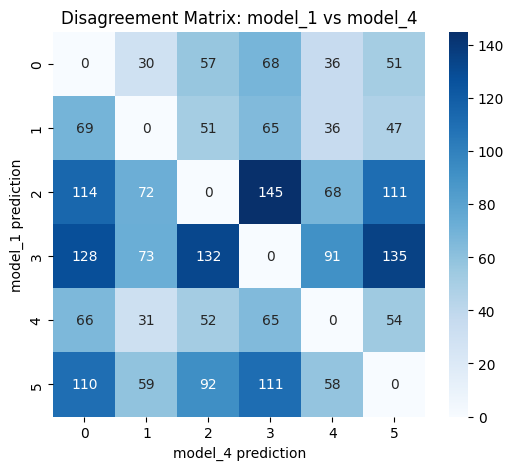

mcNemar Result {'statistic': np.float64(0.16307277628032346), 'p-value': np.float64(0.6863430996644153)}


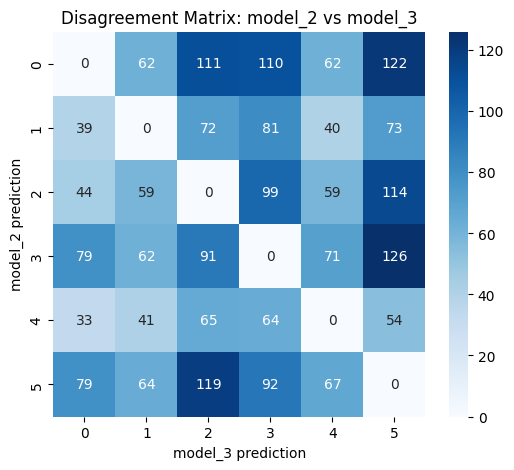

mcNemar Result {'statistic': np.float64(1.7165562913907284), 'p-value': np.float64(0.19013693003444376)}


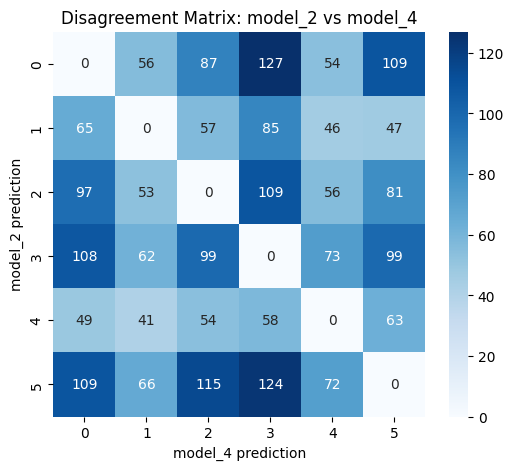

mcNemar Result {'statistic': np.float64(1.9651162790697674), 'p-value': np.float64(0.16096719697114753)}


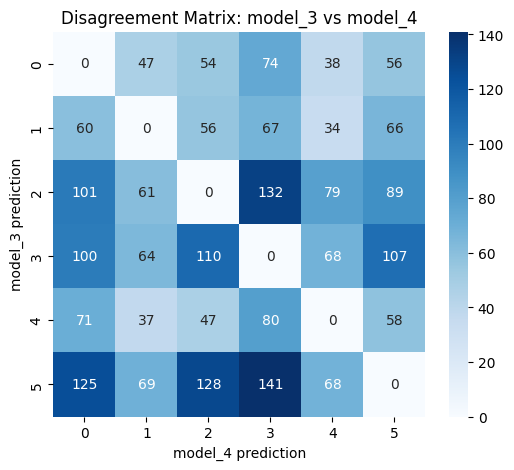

mcNemar Result {'statistic': np.float64(0.005215123859191656), 'p-value': np.float64(0.9424301599084707)}


In [42]:
#Asked Gpt to help plotting confusion matrix, and fixing label names
import seaborn as sns
import sklearn.metrics as mt

def plot_disagreement_matrix(pred_model1, pred_model2, model_1, model2, data):
	name_1 = model_1 if isinstance(model_1, str) else model_1.name
	name_2 = model2 if isinstance(model2, str) else model2.name

	mask = pred_model1 != pred_model2
	disagree_a = pred_model1[mask]
	disagree_b = pred_model2[mask]

	cm = mt.confusion_matrix(disagree_a, disagree_b)

	plt.figure(figsize=(6,5))

	sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
	plt.xlabel(f"{model2} prediction")
	plt.ylabel(f"{model_1} prediction")
	plt.title(f"Disagreement Matrix: {name_1} vs {name_2}")
	plt.show()

	print("mcNemar Result", data)

for (m1, m2), data in result.items():
	plot_disagreement_matrix(model_pred_result[m1], model_pred_result[m2], m1, m2, data)

#### Analysis

<b>Model 1 vs Model 2</b><br>
From the P result, the values is 0.06, a slightly above the 0.05 threshold, indicating that both models have no statistical difference. 

The matrix shows that that there are large disagreement between paper, and trash. Model 1 predicts labels of paper or trash differently than model 2, and model 2 behaves more consistently with the other labels. 

<b>Model 1 vs Model 3</b><br>
The P result is 0.61, shows that the models are not significantly different from one another. 

The matrix shows a similar trend with the model 1 vs 2. Trash, and paper rows still shows a high disagreement between models. Model 3 which is using dropout, and parallel pathways makes different decisions on sample that looks similar to one another. 

<b>Model 1 vs Model 4</b><br>
The P result is 0.68, shows that the models are not significantly different from one another. 

Since we are still comparing model 1 with other models, the trend still follows where the there is a high disagreement for paper, and trash labels. Model 4 disagrees with less with model 1 for cardboard and plastic compared to model 2, and 3. Additionally, model 4 seems to be making predictions that aligns with model 1. 

<b>Model 2 vs Model 3</b><br>
The P result is 0.19, which indicates that the models do not have significantly different error rates. 

This time, model 3 predicts cardboard more often than model 2, and is still struggling to differentiate between trash and paper. Since we are also using dropout for model 3, it increases the prediction variability. 

<b>Model 2 vs Model 4</b><br>
The P result for this is 0.16, indicating that the models are the same with error rate. 

The matrix between the 2 models has a high disagreement in all the classes. Model has a high disagreement rate for metal, while the model 4 has a high disagreement with trash. 

<b>Model 3 vs Model 4</b><br>
The P result is 0.94, the highest compared to all the other models suggesting that the models are statically the same.

Model 3 has a high disagreement for cardboard and paper compare to model 4, while model 4 is able to predict with less disagreement with the other models. 

Overall, this suggest that this dataset is difficult to classify despite achieving a relativity good accuracy, and it looks like each model is struggling to classify the classes correctly, and these labels were the most difficult for the models to predict: paper, trash, and metal. Which is likely due to them being looking near identical to one another. 

### 2.7 Comparing best result to standard MLP 

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1967 - loss: 1.7980 - val_accuracy: 0.2378 - val_loss: 1.7399
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2591 - loss: 1.7153 - val_accuracy: 0.2788 - val_loss: 1.6858
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2758 - loss: 1.6839 - val_accuracy: 0.2964 - val_loss: 1.6855
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3046 - loss: 1.6419 - val_accuracy: 0.2989 - val_loss: 1.6331
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3308 - loss: 1.6160 - val_accuracy: 0.3266 - val_loss: 1.6522
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3313 - loss: 1.5991 - val_accuracy: 0.3446 - val_loss: 1.6136
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3450 - loss: 1.5781 - val_accuracy: 0.3522 - val_loss: 1.5875
Epoch 8/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3466 - loss: 1.5721 - val_accu

Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_1 (Dense)             │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_2 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_3 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_dense_4 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mlp_output (Dense)              │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,276,788 (12.50 MB)

 Trainable params: 1,092,262 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,184,526 (8.33 MB)

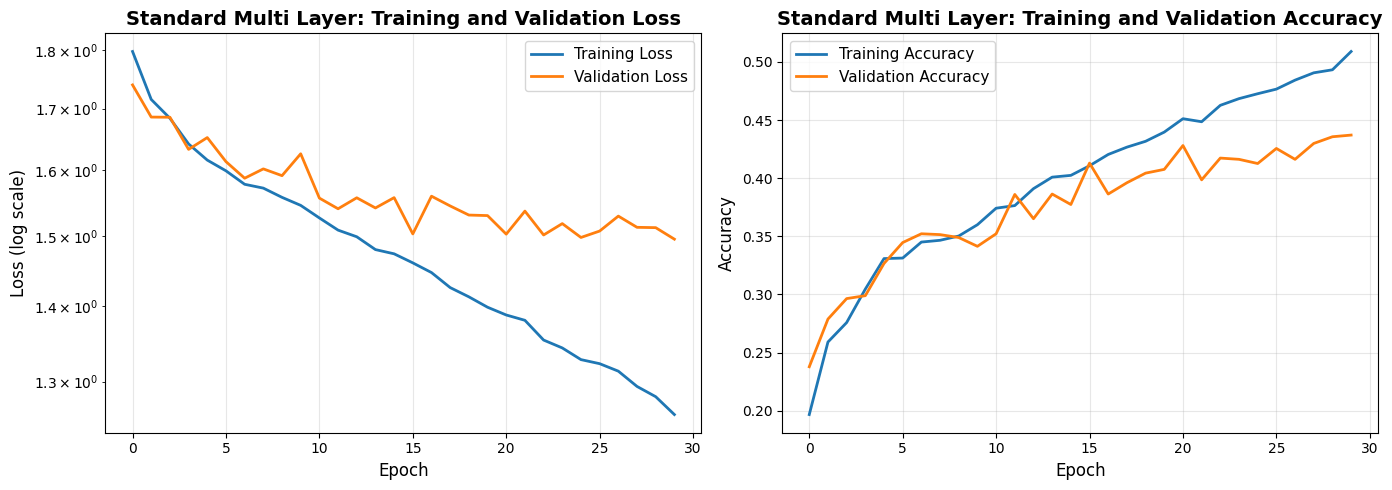

In [43]:
def four_layer_MLP():
	inputs = tf.keras.Input(shape=(64, 64, 1))
	flatten = Flatten()(inputs)

	layer1 = tf.keras.layers.Dense(256, activation="relu", name="mlp_dense_1")(flatten)
	layer2 = tf.keras.layers.Dense(128, activation="relu", name="mlp_dense_2")(layer1)
	layer3 = tf.keras.layers.Dense(64, activation="relu", name="mlp_dense_3")(layer2)
	layer4 = tf.keras.layers.Dense(32, activation="relu", name="mlp_dense_4")(layer3)

	output = tf.keras.layers.Dense(6, activation="softmax", name="mlp_output")(layer4)

	model = tf.keras.Model(inputs=inputs, outputs=output)
	return model

standard_mlp = four_layer_MLP()

standard_mlp.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_standard_mlp = standard_mlp.fit(train_ds, validation_data=test_ds, batch_size=32, epochs=30, shuffle=True, verbose=1)

standard_mlp.summary()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history_standard_mlp.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history_standard_mlp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Standard Multi Layer: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_standard_mlp.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_standard_mlp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Standard Multi Layer: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Analysis

We created a standard 4 Layer perceptron, with no dropout or data augmentation. 

The loss curve shows a downward trends for the training loss, but the model is also overfitting to the data set. As indicated by the large gap between training, and the validation loss. 

The accuracy curve shows a consistent increasing trend, but the training only reaches about 51% and  the testing accuracy achieved is still only 44%, indicating that the model is still struggling to identify the correct labels. 

Compare to our best model 2, which reached accuracy around 63%, the standard MLP performs worse. The main reason is that the MLP ignores the 2D spatial structure of the image by flattening it, so for this image classification task, convolutional architectures are more suitable than a plain MLP.

In [50]:
# custmized F score for MLP

# Get MLP predictions
y_pred_probs_mlp = standard_mlp.predict(test_ds)
y_pred_mlp = np.argmax(y_pred_probs_mlp, axis=1)

# Per-class F2 and F1
f2_per_class_mlp = fbeta_score(y_true, y_pred_mlp, beta=2, average=None)
f1_per_class_mlp = f1_score(y_true, y_pred_mlp, average=None)

# Custom weighted metric
mlp_weighted_score = (
    2 * (f2_per_class_mlp[glass] + f2_per_class_mlp[metal] + f2_per_class_mlp[trash]) +
    f1_per_class_mlp[cardboard] + f1_per_class_mlp[paper] + f1_per_class_mlp[plastic]
) / 9

print("MLP weighted F-score:", mlp_weighted_score)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MLP weighted F-score: 0.154773181936241


#### Analysis

Compared to the weighted F-score of model 2 (0.1768), MLP only got an 0.1548, which is the lowest of all the models, indicating that MLP is not only low-accuracy, but also low performance.

In [48]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.utils import to_categorical

y_true_onehot = to_categorical(y_true, num_classes=6)

model2_pred = model_2.predict(test_ds)
mlp_pred = standard_mlp.predict(test_ds)

def plot_roc_curves(model_name, y_true_onehot, y_pred_probs):
  plt.figure(figsize=(8, 6))

  for c in range(6):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, c], y_pred_probs[:, c])
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"Class {c} (AUC={auc_score:.3f})")

  plt.plot([0,1], [0,1], "k--", lw=1, label="Random Chance")
  plt.title(f"ROC Curves — {model_name}")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend()
  plt.grid(True)
  plt.show()

def compute_per_class_auroc(y_true_onehot, y_pred_probs):
  auc_list = []
  for c in range(6):
    auc_value = roc_auc_score(y_true_onehot[:, c], y_pred_probs[:, c])
    auc_list.append(auc_value)
  return auc_list

def weighted_auroc(per_class_auc):
  cardboard = 0
  glass = 1
  metal = 2
  paper = 3
  plastic = 4
  trash = 5

  high_risk = [glass, metal, trash]
  low_risk  = [cardboard, paper, plastic]

  high_sum = sum(per_class_auc[c] for c in high_risk)
  low_sum  = sum(per_class_auc[c] for c in low_risk)

  return (2 * high_sum + low_sum) / 9

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


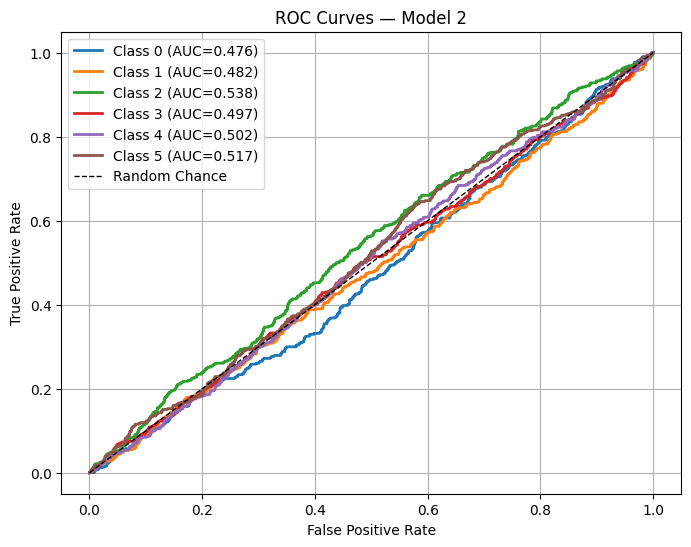

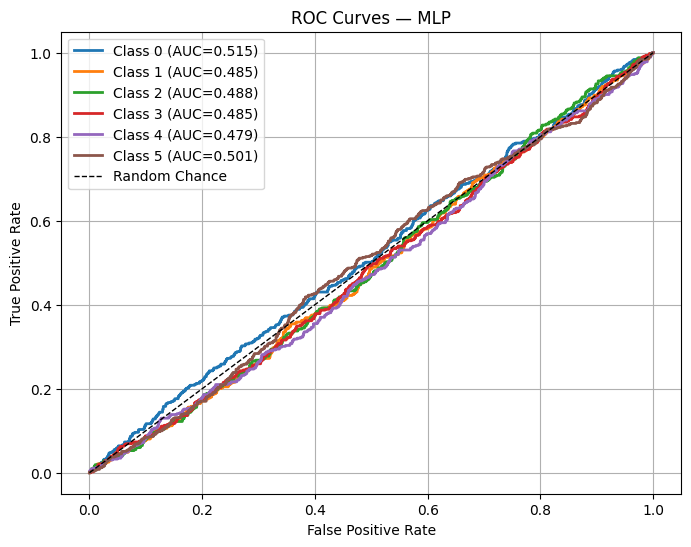

In [49]:
plot_roc_curves("Model 2", y_true_onehot, model2_pred)

plot_roc_curves("MLP", y_true_onehot, mlp_pred)

#### Analysis

The ROC curves gives us a better understanding on what the mode is doing. For both the model 2, and standard, they are randomly guessing the classes as indicated by the AUC, and the near identical line. The F2 score for the best performer now makes sense with its low values, as both the models are randomly guessing the labels across all 6 classes. 

The classes are equally distributed, but it is difficult to classifies the dataset as we resize it to a 64x64 image, and also turned into a grey image. So the images might have lost some features that could CNN to learn/extract more useful features to train the model. Additionally, some of the images are hard to distinguishable due to the loss in quality, so the model would struggle with it as well.

Creating parallel pathways did not make a difference in the model classifying the datasets, despite achieving high accuracy result. I believe that having more layers, and playing around with the learning rate might improve the result for all the models, but the garbage dataset is overall difficult to classify with our current models. 

## 3. Exceptional Work

In [54]:
# asked GPT to give suggestion and fix bugs in building ResNet50
# asked Gemini to leverage GPU

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# use strategy to leverage gpu
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices in sync: {strategy.num_replicas_in_sync}")



# reload data for transfer learning (224x224 RGB)

tl_train_ds = keras.utils.image_dataset_from_directory(
    "images",
    labels="inferred",
    label_mode="int",
    color_mode="rgb", 
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training",
)

tl_val_ds = keras.utils.image_dataset_from_directory(
    "images",
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation",
)

class_names_tl = tl_train_ds.class_names
NUM_CLASSES_TL = len(class_names_tl)

# normalize with ResNet50 preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_resnet(image, label):
    # ResNet50 standard normalization
    image = preprocess_input(image) 
    return image, label

tl_train_ds = tl_train_ds.map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
tl_val_ds   = tl_val_ds.map(preprocess_resnet, num_parallel_calls=AUTOTUNE)

tl_train_ds = tl_train_ds.prefetch(AUTOTUNE)
tl_val_ds   = tl_val_ds.prefetch(AUTOTUNE)


# modeling within strategy
with strategy.scope():
    # Build transfer learning model (ResNet50 as backbone)

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3),
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False) # freeze first
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES_TL, activation="softmax")(x)

    tl_model = keras.Model(inputs, outputs, name="resnet50_transfer")

    tl_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

tl_model.summary()

# train only the new classification head

history_tl = tl_model.fit(
    tl_train_ds,
    validation_data=tl_val_ds,
    epochs=8,
    verbose=1,
)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Number of devices in sync: 1
Found 13901 files belonging to 6 classes.
Using 11121 files for training.
Found 13901 files belonging to 6 classes.
Using 2780 files for validation.


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 153s 435ms/step - accuracy: 0.4927 - loss: 1.3635 - val_accuracy: 0.7378 - val_loss: 0.7409
Epoch 2/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 149s 428ms/step - accuracy: 0.7378 - loss: 0.7259 - val_accuracy: 0.8212 - val_loss: 0.5374
Epoch 3/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 153s 438ms/step - accuracy: 0.8032 - loss: 0.5628 - val_accuracy: 0.8424 - val_loss: 0.4594
Epoch 4/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 149s 427ms/step - accuracy: 0.8279 - loss: 0.4887 - val_accuracy: 0.8612 - val_loss: 0.4154
Epoch 5/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 148s 424ms/step - accuracy: 0.8470 - loss: 0.4407 - val_accuracy: 0.8727 - val_loss: 0.3865
Epoch 6/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 150s 432ms/step - accuracy: 0.8607 - loss: 0.4034 - val_accuracy: 0.8788 - val_loss: 0.3646
Epoch 7/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 149s 426ms/step - accuracy: 0.8682 - loss: 0.3792 - val_accuracy: 0.8874 - val_loss: 0.3478
Epoch 8/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 147s 423ms/step - accuracy: 0.8792 - loss: 0

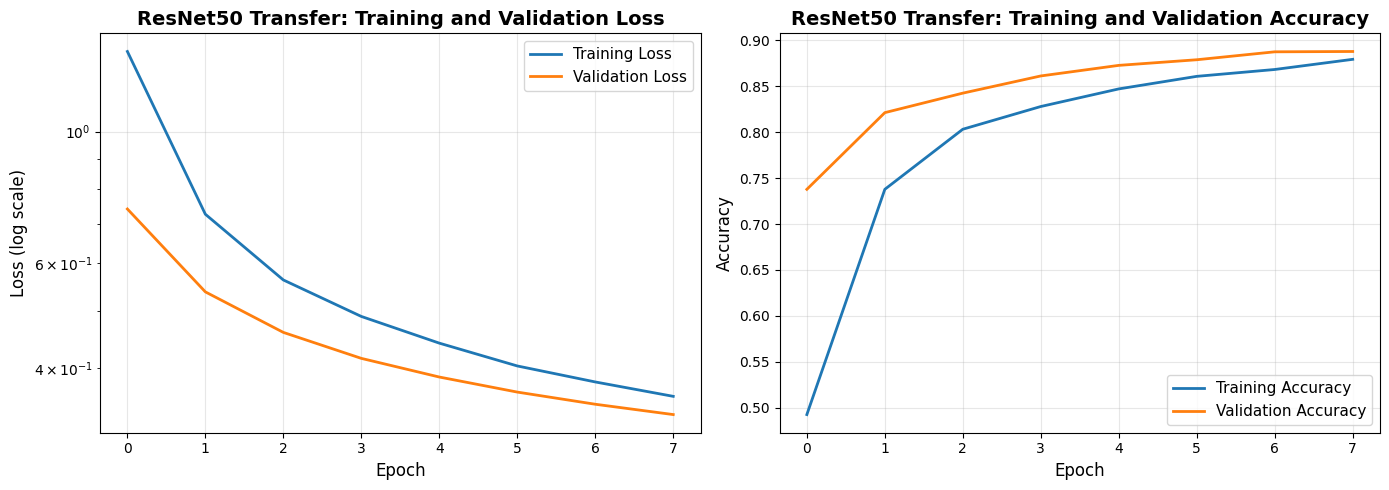

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot (log scale)
axes[0].semilogy(history_tl.history['loss'], label='Training Loss', linewidth=2)
axes[0].semilogy(history_tl.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('ResNet50 Transfer: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_tl.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_tl.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('ResNet50 Transfer: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Customized Weighted F-score for ResNet50
# Gpt fix bugs of multi depth filter

# get labels from tl_val_ds
y_true_tl = np.concatenate([y.numpy() for _, y in tl_val_ds], axis=0)

y_pred_probs_tl = tl_model.predict(tl_val_ds)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

# calculate score
f2_per_class_tl = fbeta_score(y_true_tl, y_pred_tl, beta=2, average=None)
f1_per_class_tl = f1_score(y_true_tl, y_pred_tl, average=None)

# our customized score
tl_weighted_score = (
    2 * (f2_per_class_tl[glass] + f2_per_class_tl[metal] + f2_per_class_tl[trash]) +
    f1_per_class_tl[cardboard] + f1_per_class_tl[paper] + f1_per_class_tl[plastic]
) / 9

print("Transfer Learning (ResNet50) weighted F-score:", tl_weighted_score)


87/87 ━━━━━━━━━━━━━━━━━━━━ 31s 344ms/step
Transfer Learning (ResNet50) weighted F-score: 0.1626531837760551


In [ ]:
# ask gpt to solve the different input format problems
from statsmodels.stats.contingency_tables import mcnemar

y_pred_probs_m2 = model_2.predict(test_ds)
y_pred_m2 = np.argmax(y_pred_probs_m2, axis=1)

y_pred_probs_tl = tl_model.predict(tl_val_ds)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

def mcNemar_table(y_true, model_1_pred, model_2_pred):
    model1_correct = model_1_pred == y_true
    model2_correct = model_2_pred == y_true

    both_correct = np.sum(model1_correct & model2_correct)
    m1_correct_m2_wrong = np.sum(model1_correct & ~model2_correct)
    m2_correct_m1_wrong = np.sum(~model1_correct & model2_correct)
    both_wrong = np.sum(~model1_correct & ~model2_correct)

    return np.array([[both_correct, m1_correct_m2_wrong],
                     [m2_correct_m1_wrong, both_wrong]])

table = mcNemar_table(y_true, y_pred_m2, y_pred_tl)
result_mcnemar = mcnemar(table, exact=False, correction=True)

print("McNemar statistic:", result_mcnemar.statistic)
print("McNemar p-value:", result_mcnemar.pvalue)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 327ms/step
McNemar statistic: 0.021136063408190225
McNemar p-value: 0.8844089022867729


#### Analysis

According to the result, transfer learning with ResNet50 achieved a much higher validation accuracy as 88.78% compared to our best baseline CNN Model 2 (62.05%), this result may confirm that pretrained ImageNet features highly improve overall classification performance on this dataset, but since we used 224x224 RGB images rather than 64x64 grayscaled images in previous models, the improvemence may caused by the higher quality of the images.

We then evaluated the TL model using our custom weighted F-score that emphasizes high-risk classes recall, the results show that TL model also get a low score as 0.1627, even slightly below Model 2 (0.1768). 

This inconsisgtency, high improvement in accuracy with no improvement in performance score, suggests that our metric design may be biased rather than reflecting true model quality, since we emphasis two times weight on the high-risk classes, which will lead a slightly miss-classifying will earase the overall performance of the model. So in future work, the performance mesurement design should also be improved to better reflect the model performance.

We also did the Mcnemar analysis, turns out the p-value is 0.8844, meaning the two models do not differ significantly in their misclassification patterns, despite ResNet50 having a much higher validation accuracy. It’s important to note that this McNemar test should be conducted on the same underlying test dataset, but the two models take different input formats, so in this case, the p-value reflects the similarity of their prediction errors on the same images, not a comparison of identical input pipelines.